In [1]:
# @title Imports
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from popy.config import PROJECT_PATH_LOCAL, COLORS

/home/uzsombi/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-vg7kzyy_ because there was an issue with the default path (/home/uzsombi/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
def load_res():
    # show bic and LPT values
    dfs = []
    for monkey in ['ka', 'po']:#:, 'yu_sham', 'yu_DCZ']:
        # load behavior data
        floc = os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', 'results', 'fitting', f'simulation_results_{monkey}.csv')
        res_temp = pd.read_csv(floc)

        # add monkey name to the dataframe and move to first col
        res_temp['monkey'] = monkey
        

        dfs.append(res_temp)
    return pd.concat(dfs, ignore_index=True)

def plot_res(res_all, paper_format=False):
    # Set font size and figure size
    if paper_format:
        plt.rcParams.update({'font.size': 8})
        w, h = 4, 4
    else:
        plt.rcParams.update({'font.size': 8})
        w, h = ((12/5)/3)*(len(res_all)/2), 5/1

    # Define the modes and figure
    modes = ['LPT_best']
    fig, axes = plt.subplots(2, 1, figsize=(w/2.54, h/2.54), gridspec_kw={'hspace': 0.3})

    # Get unique values
    models = res_all.loc[res_all['monkey'] != 'yu_DCZ', 'Model'].unique()
    monkeys = res_all.loc[res_all['monkey'] != 'yu_DCZ', 'monkey'].unique()

    # Iterate over the modes and plot
    for mode_idx, mode in enumerate(modes):
        # Set up positions
        x = np.arange(len(models))
        width = 0.65  # Width of bars

        for i, monkey in enumerate(monkeys):
            ax = axes[i]  # Use separate subplot for each monkey
            
            data = res_all.loc[(res_all['monkey'] == monkey) & (res_all['monkey'] != 'yu_DCZ')]
            values = [data.loc[data['Model'] == model, mode].iloc[0] if len(data.loc[data['Model'] == model]) > 0 else 0 for model in models]
            
            # Create bars with model-based coloring
            for j, (model, value) in enumerate(zip(models, values)):
                hatch = None
                if model.split()[0] == 'Standard':
                    # replace  what comes after with RL
                    color = COLORS['Standard RL']
                    if (not model == 'Standard RL - stickiness' and not paper_format) or (paper_format and not model == 'Standard RL'):
                        hatch = '///'  # Dashed filling pattern
                elif model.split()[0] == 'Inferential':
                    color = COLORS['Inferential RL']
                    if (not model == 'Inferential RL - stickiness' and not paper_format) or (paper_format and not model == 'Inferential RL'):
                        hatch = '///'  # Dashed filling pattern
                elif model.split()[0] == 'Foraging':
                    color = COLORS['Foraging']
                    if not len(model.split(" ")) == 1:
                        hatch = '///'  # Dashed filling pattern
                else:
                    color = COLORS.get(model, 'grey')
                    hatch = None
                alpha = 0.8
                
                
                bar = ax.bar(x[j], value, width, 
                    color=color, hatch=hatch,
                    edgecolor='black', linewidth=0.5, alpha=alpha)
                
                # Set hatch color to grey for RL-s models
                if model.split()[-1] == 'RL-s':
                    import matplotlib as mpl
                    mpl.rcParams['hatch.color'] = 'grey'
            
            
            for model, value in zip(models, values):
                print(f"{mode}: {monkey} {model}: {value:.2f}")

            # add monkey name (capitalized) as title, y axis a bit lower
            ax.set_title(monkey.upper(), fontsize=10, y=.85)

            # Configure axes
            ax.set_ylim(0.3, 0.85)
            ax.set_yticks(np.arange(0.3, 0.9, 0.2))
            ax.set_ylabel('LPT', fontsize=8)
            
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            ax.grid(axis='y', linestyle='dotted', alpha=0.5, zorder=0)

            # Only add x-axis labels to bottom plot
            if i == len(monkeys) - 1:  # Bottom plot
                ax.set_xticks(x)
                if paper_format:
                    ax.set_xticklabels(models, rotation=45, horizontalalignment='right')
                else:
                    ax.set_xticklabels(models, rotation=-90, horizontalalignment='center')
            else:  # Top plot
                ax.set_xticks(x)
                ax.set_xticklabels([])  # Remove x-axis labels from top plot

    return fig, axes

res_all = load_res()
#res_all = res_all.sort_values(['Model', 'monkey'])

res_all = res_all.sort_values('Model')
res_all

,Model,epsilon,alpha,alpha_unchosen,beta,V0,forgetting_rate,forgetting_threshold,stickiness_bias,b2,abandoned_bias,abandoned_decay,LL_best,BIC_best,LPT_best,Reward rate,Proba best,alpha_threshold,monkey
14,Foraging,NaN,0.439969,NaN,10.947858,0.110103,NaN,NaN,NaN,NaN,NaN,NaN,-5675.697954,11381.635784,0.788301,0.54773,0.71916,NaN,ka
29,Foraging,NaN,0.293987,NaN,6.991815,0.188963,NaN,NaN,NaN,NaN,NaN,NaN,-7831.190966,15691.260189,0.596462,0.51742,0.63682,NaN,po
28,Foraging - abandoned bias,NaN,0.307484,NaN,6.878735,0.175822,NaN,NaN,NaN,NaN,0.0,0.005413,-7832.246447,15712.623323,0.596420,0.51898,0.64016,NaN,po
13,Foraging - abandoned bias,NaN,0.408786,NaN,11.441593,0.123276,NaN,NaN,NaN,NaN,0.0,0.887742,-5672.447750,11395.295293,0.788409,0.54864,0.72098,NaN,ka
12,Foraging - abandoned bias + spatial bias,NaN,0.448793,NaN,10.053724,0.119610,NaN,NaN,NaN,-2.078071,0.0,0.909906,-5798.819365,11658.118482,0.784244,0.50087,0.59146,NaN,ka
27,Foraging - abandoned bias + spatial bias,NaN,0.465170,NaN,5.292197,0.158955,NaN,NaN,NaN,-1.019123,0.0,0.975849,-8262.522354,16582.801223,0.579725,0.48583,0.54431,NaN,po
26,Foraging - adaptive threshold,NaN,0.324007,NaN,6.163025,0.149544,NaN,NaN,NaN,NaN,NaN,NaN,-7851.059081,15740.622505,0.595681,0.51448,0.63168,0.0,po
11,Foraging - adaptive threshold,NaN,0.448725,NaN,8.615744,0.050000,NaN,NaN,NaN,NaN,NaN,NaN,-5732.414815,11505.149466,0.786430,0.53493,0.69045,0.0,ka
25,Foraging - no reset,NaN,0.445898,NaN,5.432546,0.166812,NaN,NaN,NaN,NaN,NaN,NaN,-8257.677757,16544.233772,0.579911,0.50003,0.58388,NaN,po
10,Foraging - no reset,NaN,0.448934,NaN,10.744588,0.114476,NaN,NaN,NaN,NaN,NaN,NaN,-5799.891291,11630.022458,0.784209,0.54425,0.71032,NaN,ka


In [3]:
# sort by the order of keys in MODELS (dumb solution)

from run_model_fitting import MODELS

model_order = list(MODELS.keys())
res_all['Model'] = pd.Categorical(res_all['Model'], categories=model_order, ordered=True)
res_all = res_all.sort_values('Model')
res_all

,Model,epsilon,alpha,alpha_unchosen,beta,V0,forgetting_rate,forgetting_threshold,stickiness_bias,b2,abandoned_bias,abandoned_decay,LL_best,BIC_best,LPT_best,Reward rate,Proba best,alpha_threshold,monkey
5,Repeating agent,0.153811,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-9419.759419,18849.598796,0.673820,0.40365,0.33586,NaN,ka
20,Repeating agent,0.336102,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-10380.059332,20769.744749,0.504127,0.40416,0.33342,NaN,po
0,WSLS,0.527845,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-21770.586977,43551.253913,0.401547,0.43427,0.40782,NaN,ka
15,WSLS,0.544029,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-14264.922705,28539.471495,0.390133,0.43285,0.40459,NaN,po
4,Standard RL,NaN,0.560125,NaN,7.835644,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-9072.436802,18165.033522,0.683700,0.54535,0.70260,NaN,ka
19,Standard RL,NaN,0.391676,NaN,3.831099,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-11594.481935,23208.216041,0.465306,0.50677,0.60579,NaN,po
2,Standard RL - stickiness,NaN,0.462851,NaN,5.729116,NaN,NaN,NaN,1.679159,NaN,NaN,NaN,-7084.995560,14200.230996,0.743088,0.50649,0.62562,NaN,ka
17,Standard RL - stickiness,NaN,0.117588,NaN,0.500000,NaN,NaN,NaN,1.848962,NaN,NaN,NaN,-10146.677405,20322.233066,0.511951,0.41072,0.36057,NaN,po
3,Standard RL - forgetting,NaN,0.442102,NaN,10.495709,NaN,0.647146,0.046545,NaN,NaN,NaN,NaN,-5806.129656,11652.579146,0.784004,0.55335,0.72985,NaN,ka
18,Standard RL - forgetting,NaN,0.296466,NaN,7.779924,NaN,0.643756,0.085970,NaN,NaN,NaN,NaN,-7755.298157,15549.100656,0.599456,0.53581,0.68698,NaN,po


In [4]:
# rename Inferential RL - multiple alphas + stickiness to Inferential RL - stickiness + multiple alphas, and move it to before Inferential RL - stickiness + spatial bias
res_all = res_all.replace({'Model': {'Inferential RL - multiple alphas + stickiness': 'Inferential RL - stickiness + multiple alphas'}})
# rename Standard RL - forgetting + stickiness to Standard RL - stickiness + forgetting
res_all = res_all.replace({'Model': {'Standard RL - forgetting + stickiness': 'Standard RL - stickiness + forgetting'}})

res_all

,Model,epsilon,alpha,alpha_unchosen,beta,V0,forgetting_rate,forgetting_threshold,stickiness_bias,b2,abandoned_bias,abandoned_decay,LL_best,BIC_best,LPT_best,Reward rate,Proba best,alpha_threshold,monkey
5,Repeating agent,0.153811,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-9419.759419,18849.598796,0.673820,0.40365,0.33586,NaN,ka
20,Repeating agent,0.336102,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-10380.059332,20769.744749,0.504127,0.40416,0.33342,NaN,po
0,WSLS,0.527845,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-21770.586977,43551.253913,0.401547,0.43427,0.40782,NaN,ka
15,WSLS,0.544029,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-14264.922705,28539.471495,0.390133,0.43285,0.40459,NaN,po
4,Standard RL,NaN,0.560125,NaN,7.835644,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-9072.436802,18165.033522,0.683700,0.54535,0.70260,NaN,ka
19,Standard RL,NaN,0.391676,NaN,3.831099,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-11594.481935,23208.216041,0.465306,0.50677,0.60579,NaN,po
2,Standard RL - stickiness,NaN,0.462851,NaN,5.729116,NaN,NaN,NaN,1.679159,NaN,NaN,NaN,-7084.995560,14200.230996,0.743088,0.50649,0.62562,NaN,ka
17,Standard RL - stickiness,NaN,0.117588,NaN,0.500000,NaN,NaN,NaN,1.848962,NaN,NaN,NaN,-10146.677405,20322.233066,0.511951,0.41072,0.36057,NaN,po
3,Standard RL - forgetting,NaN,0.442102,NaN,10.495709,NaN,0.647146,0.046545,NaN,NaN,NaN,NaN,-5806.129656,11652.579146,0.784004,0.55335,0.72985,NaN,ka
18,Standard RL - forgetting,NaN,0.296466,NaN,7.779924,NaN,0.643756,0.085970,NaN,NaN,NaN,NaN,-7755.298157,15549.100656,0.599456,0.53581,0.68698,NaN,po


LPT_best: ka Repeating agent: 0.67
LPT_best: ka WSLS: 0.40
LPT_best: ka Standard RL: 0.68
LPT_best: ka Standard RL - stickiness: 0.74
LPT_best: ka Standard RL - forgetting: 0.78
LPT_best: ka Standard RL - stickiness + forgetting: 0.78
LPT_best: ka Inferential RL: 0.58
LPT_best: ka Inferential RL - stickiness: 0.75
LPT_best: ka Inferential RL - stickiness + spatial bias: 0.75
LPT_best: ka Inferential RL - stickiness + multiple alphas: 0.76
LPT_best: ka Foraging - no reset: 0.78
LPT_best: ka Foraging: 0.79
LPT_best: ka Foraging - abandoned bias: 0.79
LPT_best: ka Foraging - abandoned bias + spatial bias: 0.78
LPT_best: ka Foraging - adaptive threshold: 0.79
LPT_best: po Repeating agent: 0.50
LPT_best: po WSLS: 0.39
LPT_best: po Standard RL: 0.47
LPT_best: po Standard RL - stickiness: 0.51
LPT_best: po Standard RL - forgetting: 0.60
LPT_best: po Standard RL - stickiness + forgetting: 0.60
LPT_best: po Inferential RL: 0.44
LPT_best: po Inferential RL - stickiness: 0.55
LPT_best: po Inferen

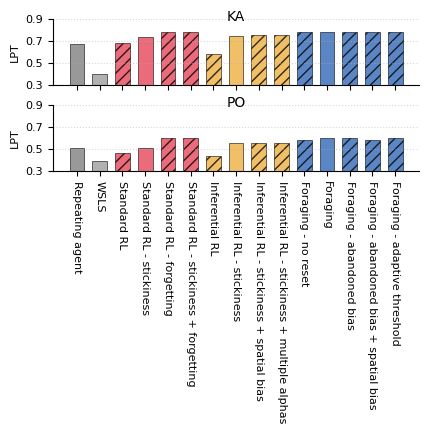

In [5]:

fig, ax = plot_res(res_all, paper_format=False)

# Adjust layout and save as SVG if needed
#plt.tight_layout()
# Uncomment the following line to save the figure
plt.savefig(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', 'figs', 'lpt.svg'), dpi=300, bbox_inches='tight', transparent=False)

plt.show()


LPT_best: ka WSLS: 0.40
LPT_best: ka Standard RL-noS: 0.68
LPT_best: ka Inferential RL-noS: 0.58
LPT_best: ka Standard RL: 0.74
LPT_best: ka Inferential RL: 0.75
LPT_best: ka Foraging: 0.79
LPT_best: po WSLS: 0.39
LPT_best: po Standard RL-noS: 0.47
LPT_best: po Inferential RL-noS: 0.44
LPT_best: po Standard RL: 0.51
LPT_best: po Inferential RL: 0.55
LPT_best: po Foraging: 0.60


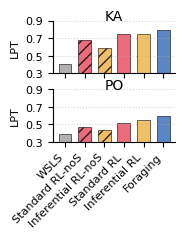

In [6]:
models_to_show = {
    'WSLS': 'WSLS',
    'Standard RL': 'Standard RL-noS',
    'Inferential RL': 'Inferential RL-noS',
    'Standard RL - stickiness': 'Standard RL',
    'Inferential RL - stickiness': 'Inferential RL',
    'Foraging': 'Foraging',
}

res_all_temp = res_all[res_all['Model'].isin(models_to_show.keys())].copy()
res_all_temp['Model'] = res_all_temp['Model'].map(models_to_show)
# sort in the order of models_to_show values, KA first and PO second
res_all_temp['Model'] = pd.Categorical(res_all_temp['Model'], categories=models_to_show.values(), ordered=True)
res_all_temp['monkey'] = pd.Categorical(res_all_temp['monkey'], categories=['ka', 'po'], ordered=True)
res_all_temp = res_all_temp.sort_values(['Model', 'monkey'])

fig, ax = plot_res(res_all_temp, paper_format=True)

# Adjust layout and save as SVG if needed
#plt.tight_layout()
# Uncomment the following line to save the figure
plt.savefig(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', 'figs', 'lpt_paper.svg'), dpi=300, bbox_inches='tight', transparent=False)

plt.show()


# Save best fit parameters to latex table (thesis + paper)

In [7]:
import re, sys
fname = 'bib.txt'
#fname = 'figs/lpt.png'
with open(fname, 'r') as f:
    text = f.read()
records = [r.strip() for r in re.split(r'\n\s*\n', text) if r.strip()]
deduped = sorted(set(records))  # sets remove duplicates; sort for stable output

# write back to file
with open(fname, 'w') as f:
    f.write('\n\n'.join(deduped))
    

FileNotFoundError: [Errno 2] No such file or directory: 'bib.txt'

# Fitting on first 10 and first 15 trials only

In [ ]:
floc = os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', 'results', 'fitting_first10', f'simulation_results_{monkey}.csv')
